# Kantamal Catchment — CAMELS-IND Data Exploration

## Objective

This notebook extracts and explores hydrometeorological data for the
Kantamal gauging station in the Mahanadi/Tel River basin from the
CAMELS-IND dataset.

**CAMELS-IND Catchment ID:** 8013  
**Station:** Kantamal  
**Basin:** Mahanadi  
**Sub-basin:** Mahanadi/Tel

The notebook will examine:

- Observed streamflow
- Data availability and missing values
- Meteorological forcing variables
- Temporal coverage
- Variables suitable for streamflow forecasting

The processed data will later be used with LSTM, BiLSTM and Transformer models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Path to CAMELS-IND observed streamflow data
streamflow_path = (
    "../data/camels_ind/"
    "CAMELS_IND_Catchments_Streamflow_Sufficient/"
    "streamflow_timeseries/"
    "streamflow_observed.csv"
)

# Load dataset
streamflow_raw = pd.read_csv(streamflow_path)

print("Dataset shape:", streamflow_raw.shape)
streamflow_raw.head()

Dataset shape: (14976, 245)


,year,month,day,3002,3005,3008,3009,3013,3014,3017,...,17005,17006,17007,17009,17011,17012,17015,17019,17022,17024
0,1980,1,1,NaN,23.2,36.1,NaN,NaN,NaN,NaN,...,2.00,3.8,NaN,NaN,12.2,2.7,0.8,23.7,10.3,18.0
1,1980,1,2,NaN,22.0,36.0,NaN,NaN,NaN,NaN,...,1.96,3.5,NaN,NaN,7.2,2.5,0.7,24.0,12.6,18.0
2,1980,1,3,NaN,21.4,36.0,NaN,NaN,NaN,NaN,...,2.22,3.1,NaN,NaN,5.8,2.1,0.0,30.0,5.8,16.0
3,1980,1,4,NaN,23.0,36.5,NaN,NaN,NaN,NaN,...,1.90,3.5,NaN,NaN,6.5,1.9,0.0,31.2,4.9,23.0
4,1980,1,5,NaN,22.2,36.7,NaN,NaN,NaN,NaN,...,1.90,3.9,NaN,NaN,5.6,1.5,0.0,32.7,5.2,16.0


In [3]:
KANTAMAL_ID = "8013"

# Make sure station IDs are treated as strings
streamflow_raw.columns = streamflow_raw.columns.astype(str)

# Construct a proper date column
streamflow_raw["date"] = pd.to_datetime(
    streamflow_raw[["year", "month", "day"]]
)

# Extract Kantamal
kantamal_flow = streamflow_raw[
    ["date", KANTAMAL_ID]
].copy()

kantamal_flow.rename(
    columns={KANTAMAL_ID: "streamflow"},
    inplace=True
)

kantamal_flow.head()

C:\Users\karthik\AppData\Local\Temp\ipykernel_29112\2135557490.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  streamflow_raw["date"] = pd.to_datetime(


,date,streamflow
0,1980-01-01,10.01
1,1980-01-02,9.73
2,1980-01-03,9.32
3,1980-01-04,12.29
4,1980-01-05,13.21


In [4]:
print("Start date:", kantamal_flow["date"].min())
print("End date:", kantamal_flow["date"].max())
print("Total days:", len(kantamal_flow))

print("\nMissing streamflow values:")
print(kantamal_flow["streamflow"].isna().sum())

print("\nAvailable observations:")
print(kantamal_flow["streamflow"].notna().sum())

missing_percent = (
    kantamal_flow["streamflow"].isna().mean() * 100
)

print(f"\nMissing percentage: {missing_percent:.2f}%")

Start date: 1980-01-01 00:00:00
End date: 2020-12-31 00:00:00
Total days: 14976

Missing streamflow values:
791

Available observations:
14185

Missing percentage: 5.28%


## Observed Streamflow Quality Assessment

Before preprocessing or model development, the observed Kantamal streamflow
record is examined for its temporal coverage, missing observations,
distribution, and possible anomalous values.

In [5]:
kantamal_flow["streamflow"].describe()

count    14185.000000
mean       348.106617
std        964.823076
min          0.000000
25%         22.920000
50%         82.330000
75%        255.520000
max      20000.000000
Name: streamflow, dtype: float64

In [6]:
missing_by_year = (
    kantamal_flow
    .assign(year=kantamal_flow["date"].dt.year)
    .groupby("year")["streamflow"]
    .apply(lambda x: x.isna().sum())
)

missing_by_year[missing_by_year > 0]

year
1980     30
1985     10
1989     28
1999     56
2018      2
2019    299
2020    366
Name: streamflow, dtype: int64

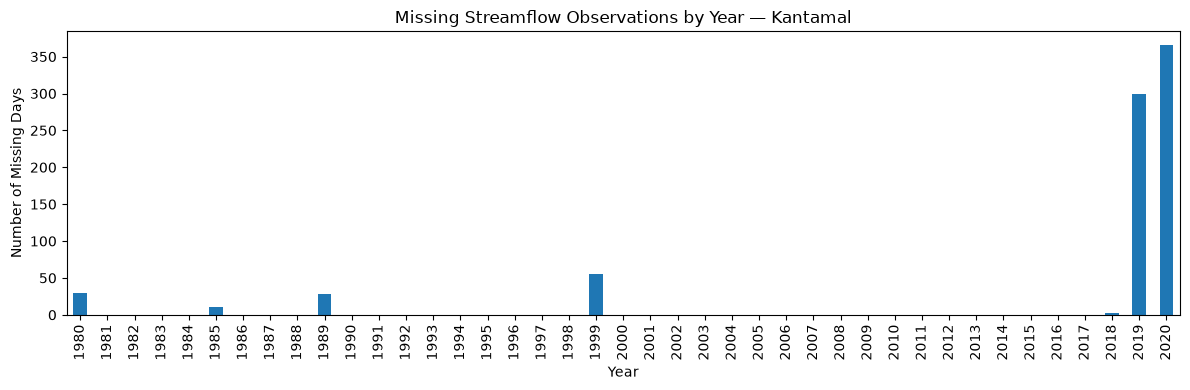

In [7]:
plt.figure(figsize=(12, 4))

missing_by_year.plot(kind="bar")

plt.title("Missing Streamflow Observations by Year — Kantamal")
plt.xlabel("Year")
plt.ylabel("Number of Missing Days")
plt.tight_layout()
plt.show()

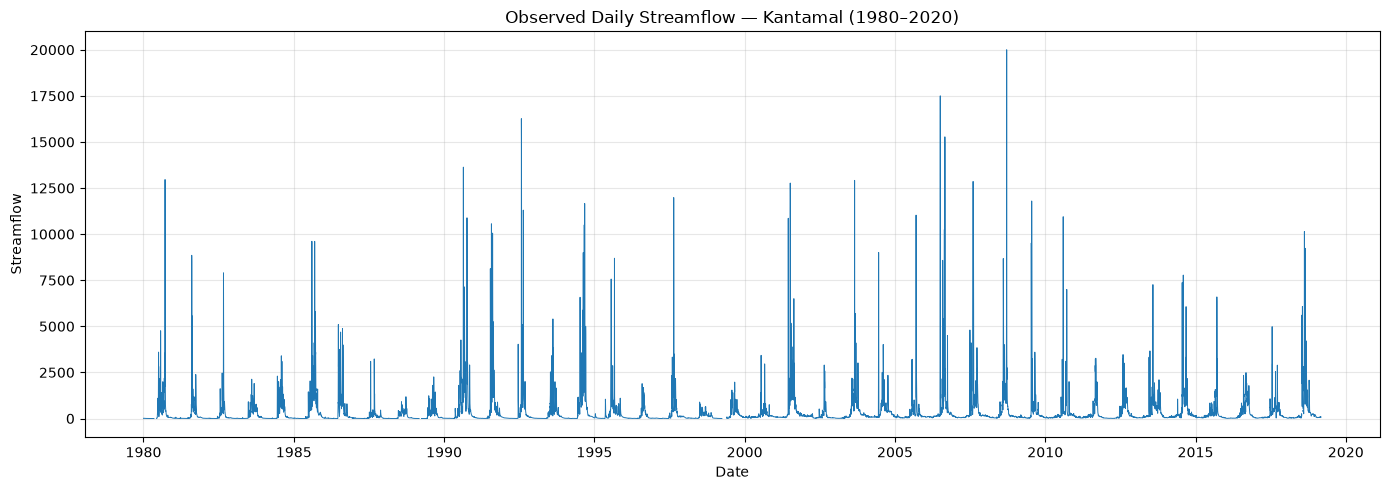

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    kantamal_flow["date"],
    kantamal_flow["streamflow"],
    linewidth=0.7
)

plt.title("Observed Daily Streamflow — Kantamal (1980–2020)")
plt.xlabel("Date")
plt.ylabel("Streamflow")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
last_valid_date = kantamal_flow.loc[
    kantamal_flow["streamflow"].notna(),
    "date"
].max()

first_valid_date = kantamal_flow.loc[
    kantamal_flow["streamflow"].notna(),
    "date"
].min()

print("First valid observation:", first_valid_date)
print("Last valid observation:", last_valid_date)

First valid observation: 1980-01-01 00:00:00
Last valid observation: 2019-03-07 00:00:00


In [10]:
missing = kantamal_flow["streamflow"].isna()

gap_group = (missing != missing.shift()).cumsum()

missing_gaps = (
    kantamal_flow[missing]
    .groupby(gap_group[missing])
    .agg(
        start=("date", "min"),
        end=("date", "max"),
        days=("date", "size")
    )
)

missing_gaps.sort_values("days", ascending=False)

,start,end,days
streamflow,,,
14,2019-03-08,2020-12-31,665
8,1999-03-31,1999-05-25,56
2,1980-05-08,1980-06-06,30
6,1989-03-04,1989-03-31,28
4,1985-05-14,1985-05-23,10
10,2018-07-15,2018-07-15,1
12,2018-07-29,2018-07-29,1


In [11]:
kantamal_flow.nlargest(15, "streamflow")

,date,streamflow
10489,2008-09-19,20000.00
9682,2006-07-05,17500.00
4592,1992-07-28,16263.00
10488,2008-09-18,16000.00
9681,2006-07-04,15278.64
9738,2006-08-30,15276.24
4593,1992-07-29,15207.00
9739,2006-08-31,14900.00
3887,1990-08-23,13633.00
262,1980-09-19,12959.80


## Catchment-Mean Meteorological Forcings

CAMELS-IND provides daily catchment-averaged meteorological forcing data for
Kantamal (Catchment ID 8013). These variables will be examined as potential
predictors of daily streamflow.

In [12]:
forcing_path = (
    "../data/camels_ind/"
    "CAMELS_IND_Catchments_Streamflow_Sufficient/"
    "catchment_mean_forcings/"
    "08013.csv"
)

forcing_raw = pd.read_csv(forcing_path)

print("Dataset shape:", forcing_raw.shape)

print("\nColumns:")
for col in forcing_raw.columns:
    print(col)

Dataset shape: (14976, 22)

Columns:
year
month
day
prcp(mm/day)
tmax(C)
tmin(C)
tavg(C)
srad_lw(w/m2)
srad_sw(w/m2)
wind_u(m/s)
wind_v(m/s)
wind(m/s)
rel_hum(%)
pet(mm/day)
pet_gleam(mm/day)
aet_gleam(mm/day)
evap_canopy(mm/day)
evap_surface(mm/day)
sm_lvl1(kg/m2)
sm_lvl2(kg/m2)
sm_lvl3(kg/m2)
sm_lvl4(kg/m2)


In [13]:
# Construct date for the forcing dataset
forcing_raw["date"] = pd.to_datetime(
    forcing_raw[["year", "month", "day"]]
)

# Remove separate date-component columns
forcing = forcing_raw.drop(
    columns=["year", "month", "day"]
).copy()

# Put date first
forcing = forcing[
    ["date"] + [col for col in forcing.columns if col != "date"]
]

# Merge meteorological forcings with observed Kantamal streamflow
kantamal_data = pd.merge(
    forcing,
    kantamal_flow,
    on="date",
    how="inner"
)

print("Merged dataset shape:", kantamal_data.shape)
print("Start date:", kantamal_data["date"].min())
print("End date:", kantamal_data["date"].max())

kantamal_data.head()

Merged dataset shape: (14976, 21)
Start date: 1980-01-01 00:00:00
End date: 2020-12-31 00:00:00


,date,prcp(mm/day),tmax(C),tmin(C),tavg(C),srad_lw(w/m2),srad_sw(w/m2),wind_u(m/s),wind_v(m/s),wind(m/s),...,pet(mm/day),pet_gleam(mm/day),aet_gleam(mm/day),evap_canopy(mm/day),evap_surface(mm/day),sm_lvl1(kg/m2),sm_lvl2(kg/m2),sm_lvl3(kg/m2),sm_lvl4(kg/m2),streamflow
0,1980-01-01,0.00,29.14,15.07,22.10,351.17,258.53,0.70,1.08,1.29,...,NaN,2.29,1.27,0.00,0.53,3.27,56.85,162.90,510.57,10.01
1,1980-01-02,0.00,29.52,16.69,23.10,366.71,253.43,0.86,0.31,0.91,...,NaN,2.23,1.32,0.03,0.49,3.20,56.73,162.62,510.38,9.73
2,1980-01-03,0.41,29.37,16.85,23.11,369.43,244.62,0.55,-0.30,0.63,...,NaN,1.81,1.09,0.28,0.48,3.21,56.61,162.33,510.16,9.32
3,1980-01-04,0.48,28.61,17.13,22.87,374.26,205.42,-1.02,-0.80,1.30,...,NaN,1.82,1.27,0.35,0.51,3.54,56.49,162.06,509.98,12.29
4,1980-01-05,1.18,25.77,16.69,21.23,372.31,243.53,-0.74,-0.04,0.74,...,NaN,1.84,1.29,0.31,0.55,3.76,56.37,161.78,509.79,13.21


In [14]:
missing_summary = pd.DataFrame({
    "missing_count": kantamal_data.isna().sum(),
    "missing_percent": kantamal_data.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_percent
streamflow,791,5.281784
pet(mm/day),366,2.443910


In [15]:
kantamal_data.drop(
    columns=["date"]
).describe().T

,count,mean,std,min,25%,50%,75%,max
prcp(mm/day),14976.0,3.817261,10.154390,0.00,0.0000,0.100,3.3000,195.08
tmax(C),14976.0,32.477773,4.132507,19.43,29.4900,31.610,35.1600,43.93
tmin(C),14976.0,20.561969,4.664860,0.00,16.7500,22.350,24.0500,30.17
tavg(C),14976.0,26.519848,4.036627,13.44,23.5375,26.940,28.8700,36.82
srad_lw(w/m2),14976.0,388.671681,41.254693,269.18,354.9825,400.245,425.2100,459.02
srad_sw(w/m2),14976.0,283.718406,64.767941,14.99,257.6200,288.200,329.7725,411.68
wind_u(m/s),14976.0,0.677424,1.399734,-7.10,-0.3500,0.470,1.6200,6.18
wind_v(m/s),14976.0,0.126454,1.198397,-7.98,-0.8400,-0.010,0.9900,5.80
wind(m/s),14976.0,1.793876,0.977471,0.04,1.1000,1.520,2.2700,8.25
rel_hum(%),14976.0,59.594361,20.057950,13.94,43.4575,58.775,78.2400,96.79


In [16]:
pet_missing = kantamal_data.loc[
    kantamal_data["pet(mm/day)"].isna(),
    "date"
]

print("First missing PET:", pet_missing.min())
print("Last missing PET:", pet_missing.max())
print("Number missing:", len(pet_missing))

print("\nMissing PET by year:")
print(pet_missing.dt.year.value_counts().sort_index())

First missing PET: 1980-01-01 00:00:00
Last missing PET: 1980-12-31 00:00:00
Number missing: 366

Missing PET by year:
date
1980    366
Name: count, dtype: int64


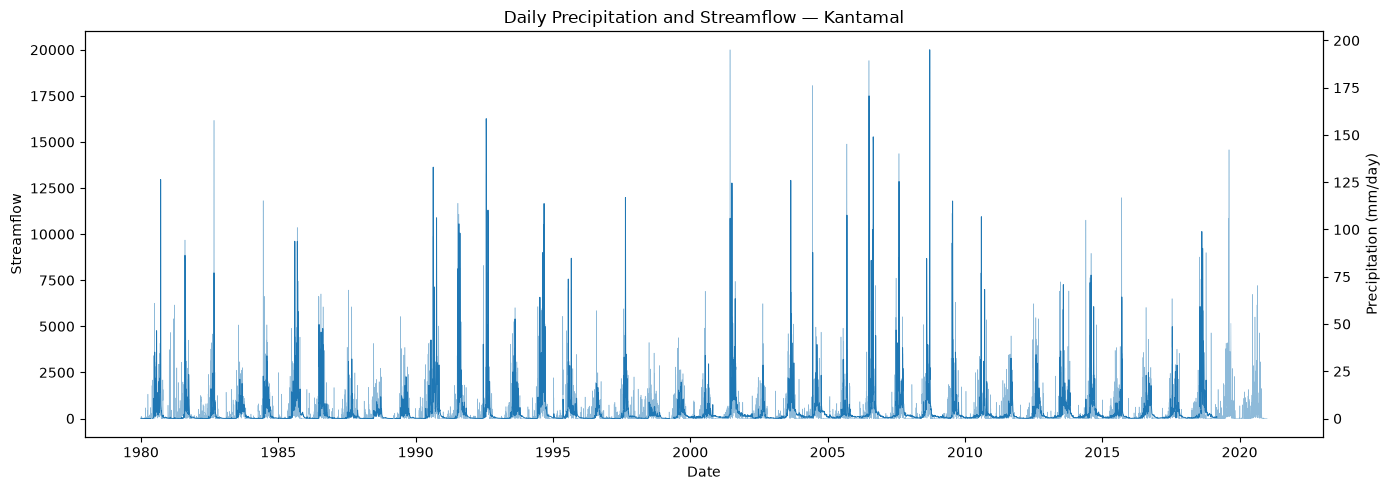

In [17]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    kantamal_data["date"],
    kantamal_data["streamflow"],
    linewidth=0.7,
    label="Streamflow"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Streamflow")

ax2 = ax1.twinx()

ax2.plot(
    kantamal_data["date"],
    kantamal_data["prcp(mm/day)"],
    linewidth=0.4,
    alpha=0.5,
    label="Precipitation"
)

ax2.set_ylabel("Precipitation (mm/day)")

plt.title("Daily Precipitation and Streamflow — Kantamal")
plt.tight_layout()
plt.show()

In [18]:
selected_features = [
    "date",
    "prcp(mm/day)",
    "tavg(C)",
    "pet_gleam(mm/day)",
    "sm_lvl1(kg/m2)",
    "sm_lvl2(kg/m2)",
    "streamflow"
]

kantamal_selected = kantamal_data[
    selected_features
].copy()

kantamal_selected.head()

,date,prcp(mm/day),tavg(C),pet_gleam(mm/day),sm_lvl1(kg/m2),sm_lvl2(kg/m2),streamflow
0,1980-01-01,0.00,22.10,2.29,3.27,56.85,10.01
1,1980-01-02,0.00,23.10,2.23,3.20,56.73,9.73
2,1980-01-03,0.41,23.11,1.81,3.21,56.61,9.32
3,1980-01-04,0.48,22.87,1.82,3.54,56.49,12.29
4,1980-01-05,1.18,21.23,1.84,3.76,56.37,13.21


## Gap-Aware Sequence Preparation

The forecasting task is formulated as **one-day-ahead streamflow prediction**.

For each prediction, the model uses the previous **30 consecutive days** of
hydrometeorological conditions and streamflow to predict streamflow on the
following day.

Windows containing missing streamflow observations or discontinuous dates are
excluded rather than interpolating long observational gaps.

In [19]:
FEATURES = [
    "prcp(mm/day)",
    "tavg(C)",
    "pet_gleam(mm/day)",
    "sm_lvl1(kg/m2)",
    "sm_lvl2(kg/m2)",
    "streamflow"
]

TARGET = "streamflow"
LOOKBACK = 30


def create_gap_aware_sequences(data, features, target, lookback=30):
    X = []
    y = []
    target_dates = []

    for i in range(lookback, len(data)):

        window = data.iloc[i - lookback:i]
        target_row = data.iloc[i]

        # The input and target must contain no missing values
        if window[features].isna().any().any():
            continue

        if pd.isna(target_row[target]):
            continue

        # All dates from the beginning of the window through
        # the target day must be consecutive calendar days.
        expected_days = lookback + 1

        actual_days = (
            target_row["date"] - window.iloc[0]["date"]
        ).days + 1

        if actual_days != expected_days:
            continue

        X.append(window[features].to_numpy(dtype=float))
        y.append(float(target_row[target]))
        target_dates.append(target_row["date"])

    return (
        np.array(X),
        np.array(y),
        np.array(target_dates)
    )


X, y, target_dates = create_gap_aware_sequences(
    kantamal_selected,
    FEATURES,
    TARGET,
    LOOKBACK
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst target date:", target_dates[0])
print("Last target date:", target_dates[-1])

X shape: (13992, 30, 6)
y shape: (13992,)

First target date: 1980-01-31 00:00:00
Last target date: 2019-03-07 00:00:00


In [20]:
# Dates immediately after known streamflow gaps
gap_end_dates = [
    pd.Timestamp("1980-06-07"),
    pd.Timestamp("1985-05-24"),
    pd.Timestamp("1989-04-01"),
    pd.Timestamp("1999-05-26"),
    pd.Timestamp("2018-07-16"),
    pd.Timestamp("2018-07-30")
]

print("Checking predictions immediately after missing-data gaps:\n")

for date in gap_end_dates:
    present = date.to_datetime64() in target_dates
    print(date.date(), "->", present)

Checking predictions immediately after missing-data gaps:

1980-06-07 -> False
1985-05-24 -> False
1989-04-01 -> False
1999-05-26 -> False
2018-07-16 -> False
2018-07-30 -> False


In [21]:
for gap_end in gap_end_dates:
    later_dates = target_dates[
        target_dates > gap_end.to_datetime64()
    ]

    if len(later_dates) > 0:
        print(
            f"After {gap_end.date()} -> "
            f"first valid target: "
            f"{pd.Timestamp(later_dates[0]).date()}"
        )

After 1980-06-07 -> first valid target: 1980-07-07
After 1985-05-24 -> first valid target: 1985-06-23
After 1989-04-01 -> first valid target: 1989-05-01
After 1999-05-26 -> first valid target: 1999-06-25
After 2018-07-16 -> first valid target: 2018-08-29
After 2018-07-30 -> first valid target: 2018-08-29


## Chronological Train–Validation–Test Split

Valid gap-aware sequences are divided chronologically into training,
validation, and testing subsets.

- Training: 70%
- Validation: 15%
- Testing: 15%

Random shuffling is not used because future observations must not be used
to train models that predict earlier periods.

In [22]:
n_samples = len(X)

train_end = int(n_samples * 0.70)
val_end = int(n_samples * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]
dates_train = target_dates[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
dates_val = target_dates[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]
dates_test = target_dates[val_end:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

print("\nTRAIN")
print(pd.Timestamp(dates_train[0]).date(), "to",
      pd.Timestamp(dates_train[-1]).date())

print("\nVALIDATION")
print(pd.Timestamp(dates_val[0]).date(), "to",
      pd.Timestamp(dates_val[-1]).date())

print("\nTEST")
print(pd.Timestamp(dates_test[0]).date(), "to",
      pd.Timestamp(dates_test[-1]).date())

Training samples: 9794
Validation samples: 2099
Testing samples: 2099

TRAIN
1980-01-31 to 2007-07-25

VALIDATION
2007-07-26 to 2013-04-23

TEST
2013-04-24 to 2019-03-07


In [23]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [24]:
n_features = X_train.shape[2]

# Flatten training sequences:
# (samples, 30, 6) -> (samples × 30, 6)
X_train_2d = X_train.reshape(-1, n_features)

# Learn feature scaling ONLY from training data
feature_scaler.fit(X_train_2d)

# Transform each dataset using the same training-fitted scaler
X_train_scaled = feature_scaler.transform(
    X_train.reshape(-1, n_features)
).reshape(X_train.shape)

X_val_scaled = feature_scaler.transform(
    X_val.reshape(-1, n_features)
).reshape(X_val.shape)

X_test_scaled = feature_scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

In [25]:
target_scaler.fit(y_train.reshape(-1, 1))

y_train_scaled = target_scaler.transform(
    y_train.reshape(-1, 1)
).ravel()

y_val_scaled = target_scaler.transform(
    y_val.reshape(-1, 1)
).ravel()

y_test_scaled = target_scaler.transform(
    y_test.reshape(-1, 1)
).ravel()

In [26]:
print("X train:", X_train_scaled.shape)
print("X validation:", X_val_scaled.shape)
print("X test:", X_test_scaled.shape)

print("\ny train:", y_train_scaled.shape)
print("y validation:", y_val_scaled.shape)
print("y test:", y_test_scaled.shape)

print("\nTraining feature scaled min:",
      X_train_scaled.min(axis=(0, 1)))

print("Training feature scaled max:",
      X_train_scaled.max(axis=(0, 1)))

X train: (9794, 30, 6)
X validation: (2099, 30, 6)
X test: (2099, 30, 6)

y train: (9794,)
y validation: (2099,)
y test: (2099,)

Training feature scaled min: [0. 0. 0. 0. 0. 0.]
Training feature scaled max: [1. 1. 1. 1. 1. 1.]


## Multivariate LSTM Model

A multivariate LSTM is developed for one-day-ahead streamflow forecasting.

Each input sequence contains 30 consecutive days of:

- Precipitation
- Mean air temperature
- GLEAM potential evapotranspiration
- Soil moisture layer 1
- Soil moisture layer 2
- Observed streamflow

The model predicts streamflow for the following day.

In [27]:
import tensorflow as tf
LOOKBACK = 30
N_FEATURES = 6

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, N_FEATURES)),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1)
])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

In [29]:
history_lstm = lstm_model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 8.1549e-04 - val_loss: 8.5980e-04
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 7.6381e-04 - val_loss: 7.7882e-04
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 6.8756e-04 - val_loss: 7.1928e-04
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 6.8006e-04 - val_loss: 7.6255e-04
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 6.7483e-04 - val_loss: 8.9294e-04
Epoch 9/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 6.5951e-04 - val_loss: 6.5829e-04
Epoch 10/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 6.2102e-04 - val_loss: 6.3587e-04
Epoch 11/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 6.3983e-0

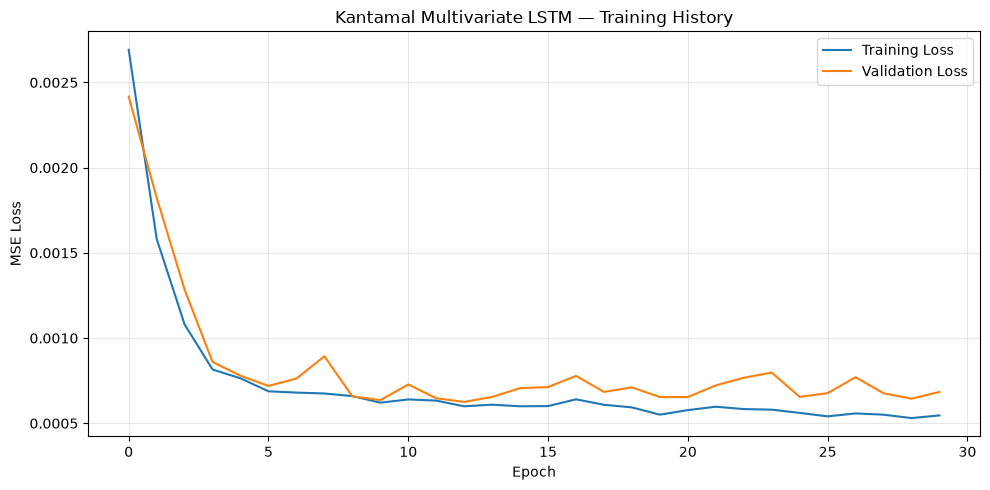

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Kantamal Multivariate LSTM — Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## LSTM Test-Set Evaluation

The trained LSTM is evaluated on the chronologically held-out test period
(2013-04-24 to 2019-03-07).

Predictions are transformed back to the original streamflow units before
calculating hydrological performance metrics.

In [31]:
# Predict normalized streamflow
y_pred_scaled = lstm_model.predict(
    X_test_scaled,
    verbose=0
)

# Convert predictions back to original streamflow units
y_pred_lstm = target_scaler.inverse_transform(
    y_pred_scaled
).ravel()

# y_test is already in original units
y_true = y_test.copy()

print("Predictions:", y_pred_lstm.shape)
print("Observations:", y_true.shape)

print("\nFirst 5 observed values:")
print(y_true[:5])

print("\nFirst 5 predicted values:")
print(y_pred_lstm[:5])

Predictions: (2099,)
Observations: (2099,)

First 5 observed values:
[114.   108.93 102.47  97.96 109.  ]

First 5 predicted values:
[154.5501  163.6104  167.36467 168.59668 165.83421]


In [32]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse_lstm = np.sqrt(
    mean_squared_error(y_true, y_pred_lstm)
)

mae_lstm = mean_absolute_error(
    y_true,
    y_pred_lstm
)

r2_lstm = r2_score(
    y_true,
    y_pred_lstm
)

nse_lstm = 1 - (
    np.sum((y_true - y_pred_lstm) ** 2)
    /
    np.sum((y_true - np.mean(y_true)) ** 2)
)

print("Kantamal Multivariate LSTM")
print("---------------------------")
print(f"RMSE : {rmse_lstm:.2f}")
print(f"MAE  : {mae_lstm:.2f}")
print(f"R²   : {r2_lstm:.4f}")
print(f"NSE  : {nse_lstm:.4f}")

Kantamal Multivariate LSTM
---------------------------
RMSE : 430.01
MAE  : 208.56
R²   : 0.5653
NSE  : 0.5653


In [33]:
STREAMFLOW_FEATURE_INDEX = FEATURES.index("streamflow")

persistence_pred = X_test[
    :, -1, STREAMFLOW_FEATURE_INDEX
]

In [34]:
rmse_persistence = np.sqrt(
    mean_squared_error(y_true, persistence_pred)
)

mae_persistence = mean_absolute_error(
    y_true,
    persistence_pred
)

r2_persistence = r2_score(
    y_true,
    persistence_pred
)

nse_persistence = 1 - (
    np.sum((y_true - persistence_pred) ** 2)
    /
    np.sum((y_true - np.mean(y_true)) ** 2)
)

print("Persistence Baseline")
print("--------------------")
print(f"RMSE : {rmse_persistence:.2f}")
print(f"MAE  : {mae_persistence:.2f}")
print(f"R²   : {r2_persistence:.4f}")
print(f"NSE  : {nse_persistence:.4f}")

Persistence Baseline
--------------------
RMSE : 436.22
MAE  : 109.61
R²   : 0.5526
NSE  : 0.5526


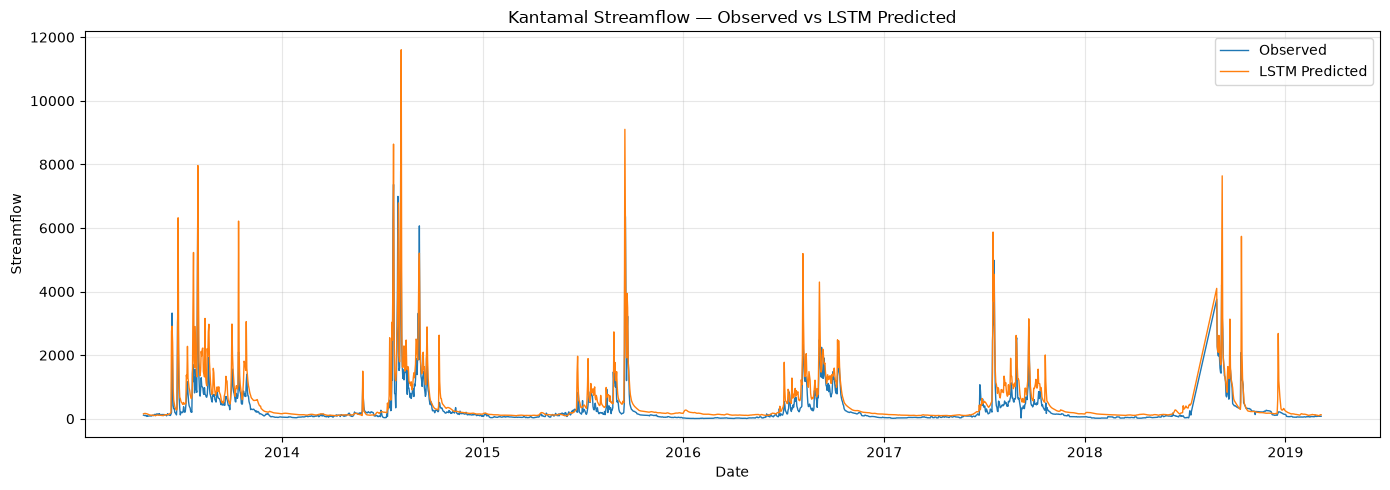

In [35]:
plt.figure(figsize=(14, 5))

plt.plot(
    dates_test,
    y_true,
    label="Observed",
    linewidth=1
)

plt.plot(
    dates_test,
    y_pred_lstm,
    label="LSTM Predicted",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Streamflow")
plt.title(
    "Kantamal Streamflow — Observed vs LSTM Predicted"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [36]:
# Identify high-flow days using the 95th percentile
high_flow_threshold = np.percentile(y_true, 95)

high_flow_mask = y_true >= high_flow_threshold

print(
    f"95th percentile threshold: "
    f"{high_flow_threshold:.2f}"
)

print(
    "Number of high-flow test days:",
    high_flow_mask.sum()
)

rmse_high = np.sqrt(
    mean_squared_error(
        y_true[high_flow_mask],
        y_pred_lstm[high_flow_mask]
    )
)

mae_high = mean_absolute_error(
    y_true[high_flow_mask],
    y_pred_lstm[high_flow_mask]
)

print(f"High-flow RMSE: {rmse_high:.2f}")
print(f"High-flow MAE : {mae_high:.2f}")

95th percentile threshold: 1317.01
Number of high-flow test days: 105
High-flow RMSE: 1398.49
High-flow MAE : 863.94


In [37]:
bias_lstm = np.mean(y_pred_lstm - y_true)

print(f"Mean prediction bias: {bias_lstm:.2f}")

print(
    "Observed mean:",
    round(np.mean(y_true), 2)
)

print(
    "Predicted mean:",
    round(np.mean(y_pred_lstm), 2)
)

Mean prediction bias: 183.35
Observed mean: 330.33
Predicted mean: 513.68


## Multivariate BiLSTM Model

A Bidirectional LSTM (BiLSTM) is trained using the same input features,
30-day lookback period, chronological data split, and preprocessing used
for the LSTM model.

This provides a controlled comparison between LSTM and BiLSTM for
one-day-ahead streamflow forecasting at Kantamal.

In [38]:
tf.random.set_seed(42)

bilstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(LOOKBACK, N_FEATURES)
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64)
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(1)
])

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,513 (158.25 KB)

 Trainable params: 40,513 (158.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

In [40]:
history_bilstm = bilstm_model.fit(
    X_train_scaled,
    y_train_scaled,

    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),

    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0018 - val_loss: 0.0026
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 8.3002e-04 - val_loss: 0.0010
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 7.3749e-04 - val_loss: 0.0010
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 7.2299e-04 - val_loss: 7.8473e-04
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 7.1992e-04 - val_loss: 8.5916e-04
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 6.3330e-04 - val_loss: 7.0977e-04
Epoch 9/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 6.4681e-04 - val_loss: 7.0097e-04
Epoch 10/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 6.4784e-04 - val_loss: 0.0011
Epoch 11/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 6.4829e-04 - val_loss:

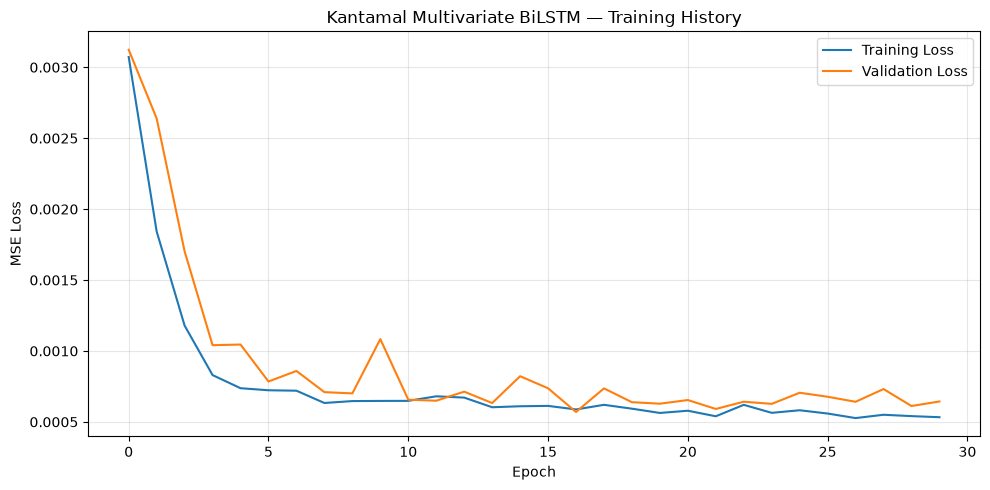

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_bilstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_bilstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Kantamal Multivariate BiLSTM — Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [42]:
y_pred_bilstm_scaled = bilstm_model.predict(
    X_test_scaled,
    verbose=0
)

y_pred_bilstm = target_scaler.inverse_transform(
    y_pred_bilstm_scaled
).ravel()

print("Predictions:", y_pred_bilstm.shape)
print("Observations:", y_true.shape)

print("\nFirst 5 observed:")
print(y_true[:5])

print("\nFirst 5 BiLSTM predicted:")
print(y_pred_bilstm[:5])

Predictions: (2099,)
Observations: (2099,)

First 5 observed:
[114.   108.93 102.47  97.96 109.  ]

First 5 BiLSTM predicted:
[131.363   128.40219 123.27907 123.5189  121.2285 ]


In [43]:
rmse_bilstm = np.sqrt(
    mean_squared_error(y_true, y_pred_bilstm)
)

mae_bilstm = mean_absolute_error(
    y_true,
    y_pred_bilstm
)

r2_bilstm = r2_score(
    y_true,
    y_pred_bilstm
)

nse_bilstm = 1 - (
    np.sum((y_true - y_pred_bilstm) ** 2)
    /
    np.sum((y_true - np.mean(y_true)) ** 2)
)

print("Kantamal Multivariate BiLSTM")
print("----------------------------")
print(f"RMSE : {rmse_bilstm:.2f}")
print(f"MAE  : {mae_bilstm:.2f}")
print(f"R²   : {r2_bilstm:.4f}")
print(f"NSE  : {nse_bilstm:.4f}")

Kantamal Multivariate BiLSTM
----------------------------
RMSE : 400.71
MAE  : 187.82
R²   : 0.6225
NSE  : 0.6225


In [44]:
rmse_high_bilstm = np.sqrt(
    mean_squared_error(
        y_true[high_flow_mask],
        y_pred_bilstm[high_flow_mask]
    )
)

mae_high_bilstm = mean_absolute_error(
    y_true[high_flow_mask],
    y_pred_bilstm[high_flow_mask]
)

bias_bilstm = np.mean(
    y_pred_bilstm - y_true
)

print(f"High-flow RMSE : {rmse_high_bilstm:.2f}")
print(f"High-flow MAE  : {mae_high_bilstm:.2f}")
print(f"Mean bias      : {bias_bilstm:.2f}")
print(f"Observed mean  : {np.mean(y_true):.2f}")
print(f"Predicted mean : {np.mean(y_pred_bilstm):.2f}")

High-flow RMSE : 1304.02
High-flow MAE  : 855.49
Mean bias      : 149.11
Observed mean  : 330.33
Predicted mean : 479.45


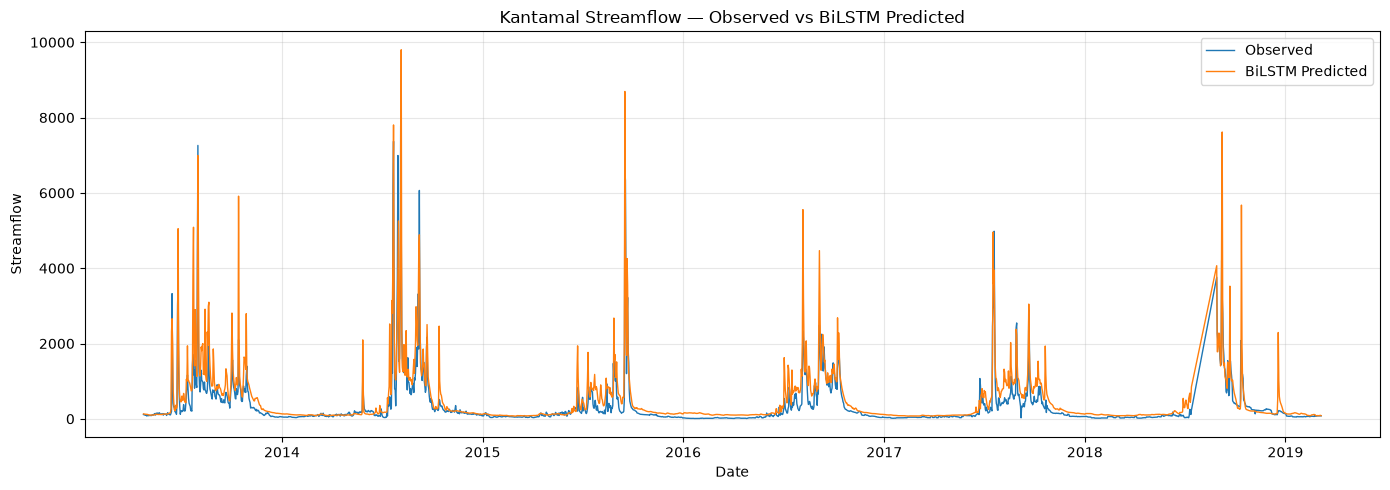

In [45]:
plt.figure(figsize=(14, 5))

plt.plot(
    dates_test,
    y_true,
    label="Observed",
    linewidth=1
)

plt.plot(
    dates_test,
    y_pred_bilstm,
    label="BiLSTM Predicted",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Streamflow")
plt.title(
    "Kantamal Streamflow — Observed vs BiLSTM Predicted"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

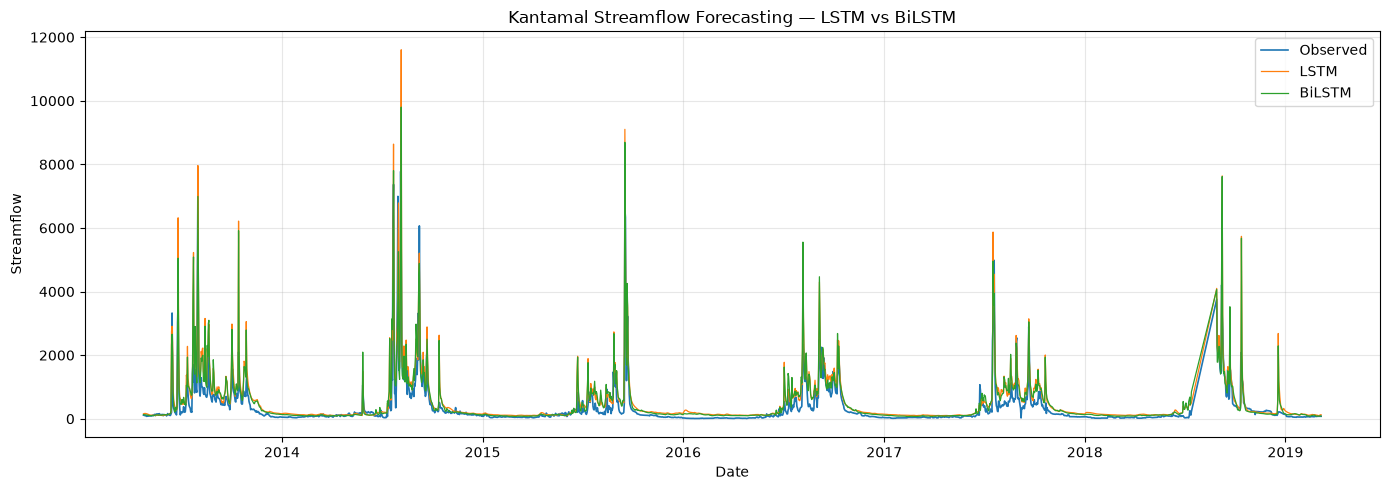

In [46]:
plt.figure(figsize=(14, 5))

plt.plot(
    dates_test,
    y_true,
    label="Observed",
    linewidth=1.2
)

plt.plot(
    dates_test,
    y_pred_lstm,
    label="LSTM",
    linewidth=0.9
)

plt.plot(
    dates_test,
    y_pred_bilstm,
    label="BiLSTM",
    linewidth=0.9
)

plt.xlabel("Date")
plt.ylabel("Streamflow")
plt.title(
    "Kantamal Streamflow Forecasting — LSTM vs BiLSTM"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Multivariate Transformer Model

A Transformer-based model is developed for one-day-ahead streamflow
forecasting using the same 30-day input sequences and six hydrological
variables used by the LSTM and BiLSTM models.

Positional embeddings are included so that the model can distinguish the
temporal position of each observation within the 30-day input window.

The same training, validation, and test datasets are retained to provide
a consistent comparison among LSTM, BiLSTM, and Transformer models.

In [48]:
tf.random.set_seed(42)

SEQ_LEN = LOOKBACK
D_MODEL = 32

# Input: 30 days × 6 features
inputs = tf.keras.Input(
    shape=(SEQ_LEN, N_FEATURES)
)

# Project six features into a 32-dimensional representation
x = tf.keras.layers.Dense(D_MODEL)(inputs)

# Learnable positional information
positions = tf.range(
    start=0,
    limit=SEQ_LEN,
    delta=1
)

position_embedding = tf.keras.layers.Embedding(
    input_dim=SEQ_LEN,
    output_dim=D_MODEL
)(positions)

x = x + position_embedding

# Multi-head self-attention
attention_output = tf.keras.layers.MultiHeadAttention(
    num_heads=4,
    key_dim=8
)(x, x)

attention_output = tf.keras.layers.Dropout(0.1)(
    attention_output
)

# Residual connection + normalization
x = tf.keras.layers.LayerNormalization(
    epsilon=1e-6
)(x + attention_output)

# Feed-forward network
ffn = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

ffn = tf.keras.layers.Dense(
    D_MODEL
)(ffn)

ffn = tf.keras.layers.Dropout(0.1)(ffn)

# Second residual connection
x = tf.keras.layers.LayerNormalization(
    epsilon=1e-6
)(x + ffn)

# Convert temporal representations into forecast
x = tf.keras.layers.Flatten()(x)

x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.1)(x)

outputs = tf.keras.layers.Dense(1)(x)

transformer_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Kantamal_Transformer"
)

transformer_model.summary()

Model: "Kantamal_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 32)    │        224 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 32)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 32)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30, 32)    │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 32)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 960)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │     61,504 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,337 (274.75 KB)

 Trainable params: 70,337 (274.75 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

In [50]:
history_transformer = transformer_model.fit(
    X_train_scaled,
    y_train_scaled,

    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),

    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.2816 - val_loss: 0.0034
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0027 - val_loss: 0.0031
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0027 - val_loss: 0.0031
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026 - val_loss: 0.0031
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026 - val_loss: 0.0032
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0024 - val_loss: 0.0031
Epoch 9/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0024 - val_loss: 0.0030
Epoch 10/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0023 - val_loss: 0.0031
Epoch 11/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0022 - val_loss: 0.0031
Epoch 12/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

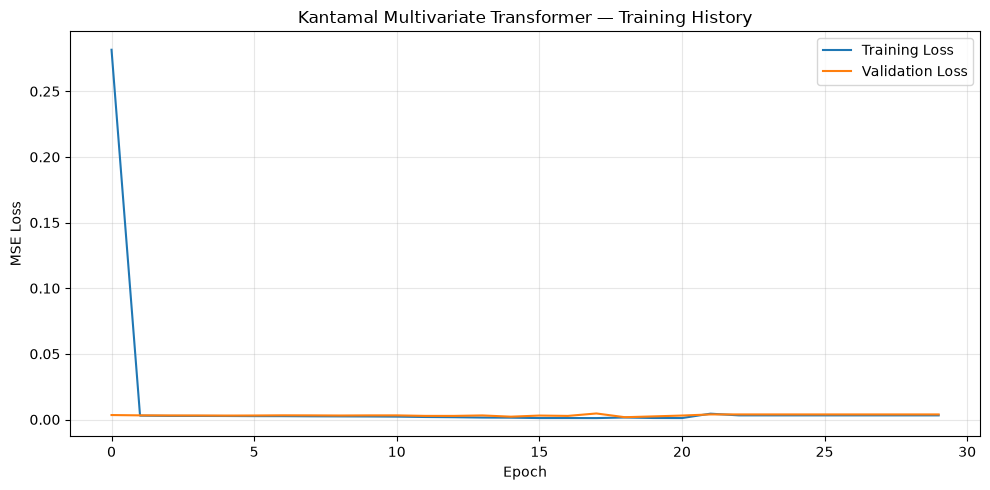

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_transformer.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_transformer.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "Kantamal Multivariate Transformer — Training History"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [52]:
y_pred_transformer_scaled = transformer_model.predict(
    X_test_scaled,
    verbose=0
)

y_pred_transformer = target_scaler.inverse_transform(
    y_pred_transformer_scaled
).ravel()

print("Predictions:", y_pred_transformer.shape)
print("Observations:", y_true.shape)

print("\nFirst 5 observed:")
print(y_true[:5])

print("\nFirst 5 Transformer predicted:")
print(y_pred_transformer[:5])

Predictions: (2099,)
Observations: (2099,)

First 5 observed:
[114.   108.93 102.47  97.96 109.  ]

First 5 Transformer predicted:
[422.5733 422.5733 422.5733 422.5733 422.5733]


In [53]:
rmse_transformer = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred_transformer
    )
)

mae_transformer = mean_absolute_error(
    y_true,
    y_pred_transformer
)

r2_transformer = r2_score(
    y_true,
    y_pred_transformer
)

nse_transformer = 1 - (
    np.sum(
        (y_true - y_pred_transformer) ** 2
    )
    /
    np.sum(
        (y_true - np.mean(y_true)) ** 2
    )
)

print("Kantamal Multivariate Transformer")
print("---------------------------------")
print(f"RMSE : {rmse_transformer:.2f}")
print(f"MAE  : {mae_transformer:.2f}")
print(f"R²   : {r2_transformer:.4f}")
print(f"NSE  : {nse_transformer:.4f}")

Kantamal Multivariate Transformer
---------------------------------
RMSE : 658.68
MAE  : 400.56
R²   : -0.0200
NSE  : -0.0200


In [54]:
rmse_high_transformer = np.sqrt(
    mean_squared_error(
        y_true[high_flow_mask],
        y_pred_transformer[high_flow_mask]
    )
)

mae_high_transformer = mean_absolute_error(
    y_true[high_flow_mask],
    y_pred_transformer[high_flow_mask]
)

bias_transformer = np.mean(
    y_pred_transformer - y_true
)

print(
    f"High-flow RMSE : "
    f"{rmse_high_transformer:.2f}"
)

print(
    f"High-flow MAE  : "
    f"{mae_high_transformer:.2f}"
)

print(
    f"Mean bias      : "
    f"{bias_transformer:.2f}"
)

print(
    f"Observed mean  : "
    f"{np.mean(y_true):.2f}"
)

print(
    f"Predicted mean : "
    f"{np.mean(y_pred_transformer):.2f}"
)

High-flow RMSE : 2545.77
High-flow MAE  : 2072.05
Mean bias      : 92.24
Observed mean  : 330.33
Predicted mean : 422.57


In [55]:
print("Prediction minimum:",
      y_pred_transformer.min())

print("Prediction maximum:",
      y_pred_transformer.max())

print("Prediction mean:",
      y_pred_transformer.mean())

print("Prediction standard deviation:",
      y_pred_transformer.std())

print("\nObserved standard deviation:",
      y_true.std())

Prediction minimum: 422.5733
Prediction maximum: 422.5733
Prediction mean: 422.57324
Prediction standard deviation: 6.1035156e-05

Observed standard deviation: 652.1853139772605


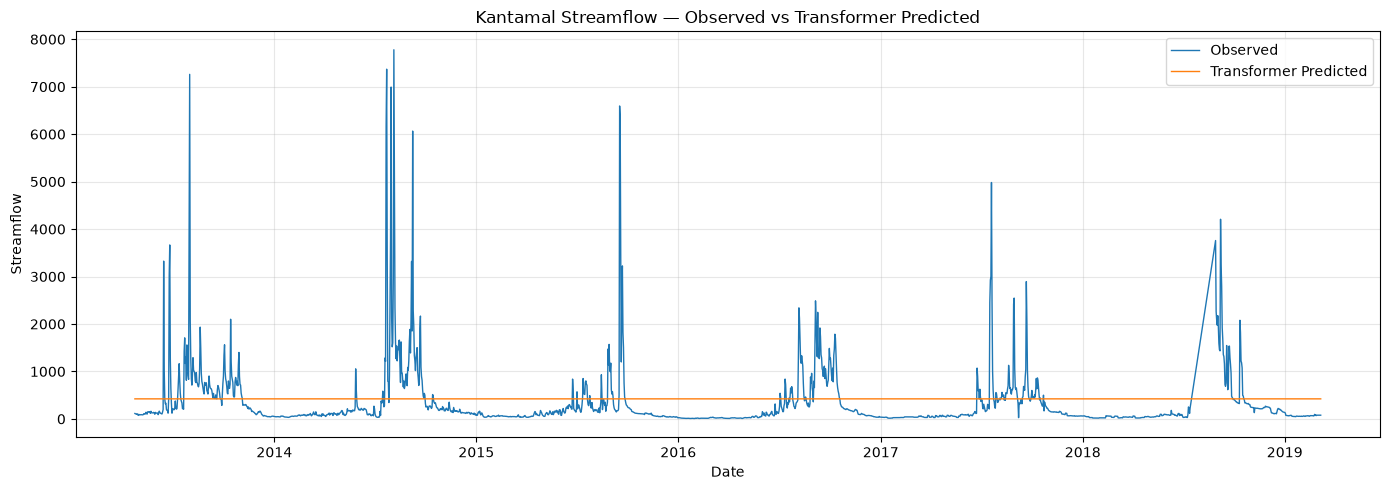

In [56]:
plt.figure(figsize=(14, 5))

plt.plot(
    dates_test,
    y_true,
    label="Observed",
    linewidth=1
)

plt.plot(
    dates_test,
    y_pred_transformer,
    label="Transformer Predicted",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Streamflow")
plt.title(
    "Kantamal Streamflow — Observed vs Transformer Predicted"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [58]:
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    MultiHeadAttention,
    LayerNormalization,
    Embedding,
    GlobalAveragePooling1D
)
tf.keras.backend.clear_session()

D_MODEL = 32

inputs = tf.keras.Input(
    shape=(LOOKBACK, N_FEATURES)
)

# Project the 6 input features into D_MODEL dimensions
x = Dense(D_MODEL)(inputs)

# Positional embeddings
positions = tf.range(
    start=0,
    limit=LOOKBACK,
    delta=1
)

position_embedding = Embedding(
    input_dim=LOOKBACK,
    output_dim=D_MODEL
)(positions)

x = x + position_embedding

# Self-attention
attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=8
)(x, x)

attention_output = Dropout(0.1)(
    attention_output
)

x = LayerNormalization(
    epsilon=1e-6
)(
    x + attention_output
)

# Feed-forward network
ffn = Dense(
    64,
    activation="relu"
)(x)

ffn = Dense(
    D_MODEL
)(ffn)

ffn = Dropout(0.1)(ffn)

x = LayerNormalization(
    epsilon=1e-6
)(
    x + ffn
)

# IMPORTANT CHANGE
x = GlobalAveragePooling1D()(x)

x = Dense(
    32,
    activation="relu"
)(x)

x = Dropout(0.1)(x)

outputs = Dense(1)(x)

transformer_v2 = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

transformer_v2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 32)    │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 32)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 32)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 32)    │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
transformer_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

In [60]:
history_transformer_v2 = transformer_v2.fit(
    X_train_scaled,
    y_train_scaled,

    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),

    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0172 - val_loss: 0.0035
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026 - val_loss: 0.0032
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026 - val_loss: 0.0033
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0026 - val_loss: 0.0032
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0026 - val_loss: 0.0033
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0025 - val_loss: 0.0036
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0025 - val_loss: 0.0031
Epoch 9/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 10/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 11/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0024 - val_loss: 0.0031
Epoch 12/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

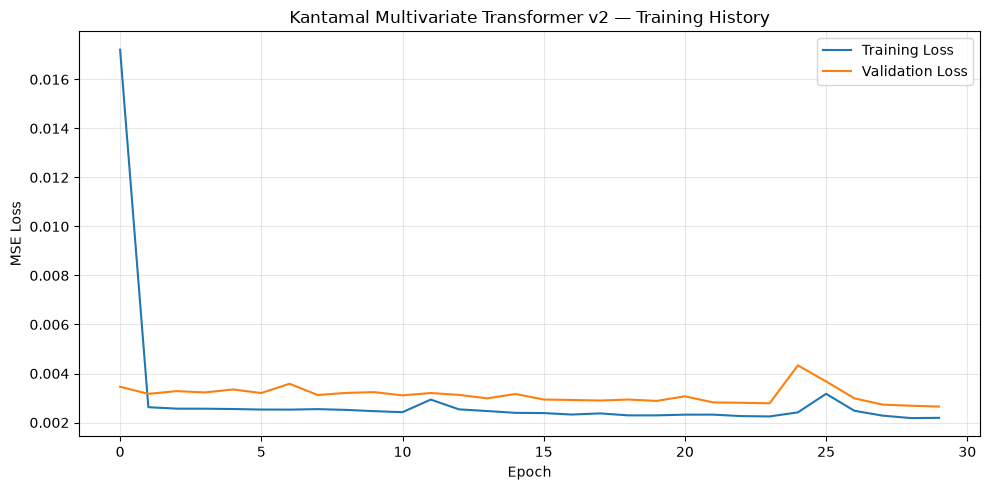

In [61]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_transformer_v2.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_transformer_v2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Kantamal Multivariate Transformer v2 — Training History"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [62]:
y_pred_transformer_v2_scaled = transformer_v2.predict(
    X_test_scaled,
    verbose=0
)

y_pred_transformer_v2 = target_scaler.inverse_transform(
    y_pred_transformer_v2_scaled
).ravel()

print("Predictions:", y_pred_transformer_v2.shape)
print("Observations:", y_true.shape)

print("\nFirst 5 observed:")
print(y_true[:5])

print("\nFirst 5 Transformer v2 predicted:")
print(y_pred_transformer_v2[:5])

print("\nPrediction range:")
print("Min :", y_pred_transformer_v2.min())
print("Max :", y_pred_transformer_v2.max())
print("Mean:", y_pred_transformer_v2.mean())
print("Std :", y_pred_transformer_v2.std())

print("\nObserved std:", y_true.std())

Predictions: (2099,)
Observations: (2099,)

First 5 observed:
[114.   108.93 102.47  97.96 109.  ]

First 5 Transformer v2 predicted:
[136.30896 136.60654 137.33316 139.09494 139.1828 ]

Prediction range:
Min : 92.922844
Max : 2362.468
Mean: 354.09445
Std : 419.00787

Observed std: 652.1853139772605


In [63]:
rmse_transformer_v2 = np.sqrt(
    mean_squared_error(y_true, y_pred_transformer_v2)
)

mae_transformer_v2 = mean_absolute_error(
    y_true, y_pred_transformer_v2
)

r2_transformer_v2 = r2_score(
    y_true, y_pred_transformer_v2
)

nse_transformer_v2 = 1 - (
    np.sum((y_true - y_pred_transformer_v2) ** 2)
    /
    np.sum((y_true - np.mean(y_true)) ** 2)
)

print("Kantamal Multivariate Transformer v2")
print("------------------------------------")
print(f"RMSE : {rmse_transformer_v2:.2f}")
print(f"MAE  : {mae_transformer_v2:.2f}")
print(f"R²   : {r2_transformer_v2:.4f}")
print(f"NSE  : {nse_transformer_v2:.4f}")

Kantamal Multivariate Transformer v2
------------------------------------
RMSE : 477.77
MAE  : 204.86
R²   : 0.4633
NSE  : 0.4633


In [64]:
rmse_high_transformer_v2 = np.sqrt(
    mean_squared_error(
        y_true[high_flow_mask],
        y_pred_transformer_v2[high_flow_mask]
    )
)

mae_high_transformer_v2 = mean_absolute_error(
    y_true[high_flow_mask],
    y_pred_transformer_v2[high_flow_mask]
)

bias_transformer_v2 = np.mean(
    y_pred_transformer_v2 - y_true
)

print(f"High-flow RMSE : {rmse_high_transformer_v2:.2f}")
print(f"High-flow MAE  : {mae_high_transformer_v2:.2f}")
print(f"Mean bias      : {bias_transformer_v2:.2f}")

High-flow RMSE : 1861.44
High-flow MAE  : 1311.08
Mean bias      : 23.76


In [65]:
model_results = pd.DataFrame({
    "Model": [
        "Persistence",
        "LSTM",
        "BiLSTM",
        "Transformer_v1",
        "Transformer_v2"
    ],

    "RMSE": [
        436.22,
        rmse_lstm,
        rmse_bilstm,
        rmse_transformer,
        rmse_transformer_v2
    ],

    "MAE": [
        109.61,
        mae_lstm,
        mae_bilstm,
        mae_transformer,
        mae_transformer_v2
    ],

    "R2": [
        0.5526,
        r2_lstm,
        r2_bilstm,
        r2_transformer,
        r2_transformer_v2
    ],

    "NSE": [
        0.5526,
        nse_lstm,
        nse_bilstm,
        nse_transformer,
        nse_transformer_v2
    ]
})

model_results

,Model,RMSE,MAE,R2,NSE
0,Persistence,436.220000,109.610000,0.552600,0.552600
1,LSTM,430.011906,208.557370,0.565271,0.565271
2,BiLSTM,400.710482,187.822697,0.622498,0.622498
3,Transformer_v1,658.675831,400.561910,-0.020003,-0.020003
4,Transformer_v2,477.771935,204.862278,0.463340,0.463340


In [66]:
model_results.to_csv(
    "../results/kantamal_model_comparison.csv",
    index=False
)

print("Saved: results/kantamal_model_comparison.csv")

Saved: results/kantamal_model_comparison.csv
